<a href="https://colab.research.google.com/github/priyankasiddaraj76/polynomial-linear-regression/blob/master/Polynomial_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, SGDRegressor

from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

In [2]:
# Generating dataset
X=6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.rand(200, 1)

#  y = 0.8x^2 + 0.9x + 2 -> polynomial function

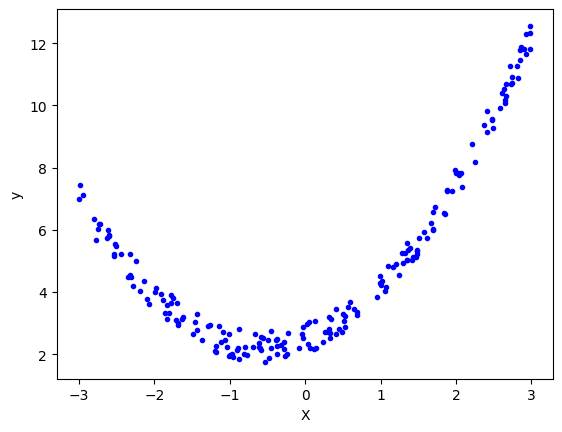

In [3]:
plt.plot(X, y, 'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

**Applying normal linear regression**

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [5]:
# Applying linear regression
lr = LinearRegression()

In [6]:
lr.fit(X_train, y_train)

LinearRegression()

In [7]:
y_pred = lr.predict(X_test)
r2_score(y_test, y_pred)
# r2_score is very less for linear regression

0.3042324682326599

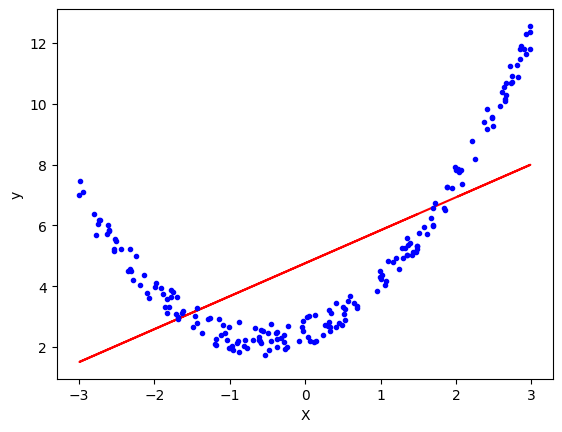

In [8]:
plt.plot(X_train, lr.predict(X_train), color='r')
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

**Applying Simple Polynomial Linear Regression**

In [9]:
# Degree 2
poly = PolynomialFeatures(degree=2)

# Trainsforming input column with polynomial values
X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [10]:
print(X_train[0])
print(X_train_trans[0])

[1.48240083]
[1.         1.48240083 2.19751222]


In [11]:
lr = LinearRegression()
lr.fit(X_train_trans, y_train)

LinearRegression()

In [12]:
y_pred = lr.predict(X_test_trans)

In [13]:
r2_score(y_test, y_pred)
# score improved drastically with polynomial LR

0.9904363318026693

In [14]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.8880524  0.80655634]]
[2.46973569]


In [15]:
X_new = np.linspace(-3, 3, 200).reshape(200,1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

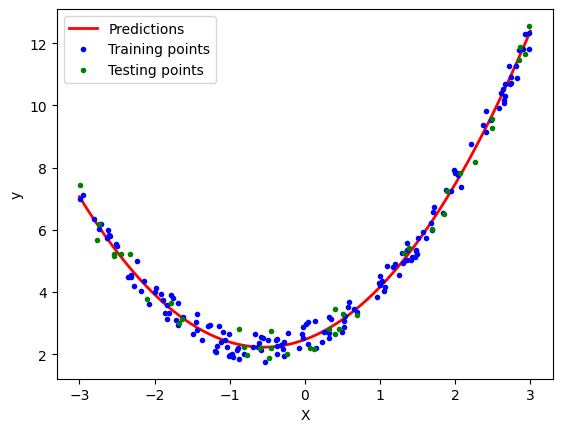

In [16]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.", label='Training points')
plt.plot(X_test, y_test, "g.", label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

**Applying Polynomial Regression for multiple input columns (higher degree)**

In [17]:
#  3D polynomial regression
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2
z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y + 2 + np.random.rand(100,1)

In [18]:
import plotly. express as px

df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [19]:
# Applying normal multiple linear regression

lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2), z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input, y_input)

final = np.vstack((xGrid.ravel().reshape(1, 100), yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

In [20]:
import plotly.graph_objects as go

fig = px.scatter_3d(df, x=x.ravel(), y = y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z = z_final))

fig.show()

In [21]:
# Applying multiple Polynomial LR
X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)

In [22]:
poly = PolynomialFeatures(degree = 2)
X_multi_trans = poly.fit_transform(X_multi)

In [23]:
print("Input", poly.n_features_in_)
print("Output", poly.n_output_features_)
print("Powers\n", poly.powers_)

Input 2
Output 6
Powers
 [[0 0]
 [1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]]


In [24]:
X_multi_trans.shape

(100, 6)

In [25]:
lr = LinearRegression()
lr.fit(X_multi_trans, z)

LinearRegression()

In [26]:
X_test_multi = poly.transform(final)

In [27]:
z_final = lr.predict(X_multi_trans).reshape(10,10)

In [28]:
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.add_trace(go.Surface(x = x_input, y = y_input, z = z_final))
fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))
fig.show()